# Задача: Анализ эффективности нового алгоритма рекомендаций в условиях асимметричного и зашумленного распределения
### Контекст:
Крупная стриминговая платформа (аналог YouTube или Twitch) разработала новый алгоритм рекомендаций контента (алгоритм B), который, как ожидается, должен увеличить среднее время просмотра на пользователя по сравнению со старым алгоритмом (A).

Было проведено A/B-тестирование:

- **Группа A (Контрольная)**: 5000 пользователей, старый алгоритм.

- **Группа B (Тестовая)**: 5000 пользователей, новый алгоритм.

По итогам двухнедельного теста вы собрали данные по ключевой метрике — **«Общее время просмотра на пользователя за тест (в минутах)»**.

**Данные и их особенности:**

**Не нормальность:** Распределение метрики в обеих группах сильно отличается от нормального. Оно имеет типичный для поведенческих данных "длинный хвост":

- Большинство пользователей смотрят немного (пик в районе 0-50 минут).

- Небольшая группа "супер-зрителей" смотрит очень много (сотни и тысячи минут), формируя длинный правый хвост распределения.

**Асимметрия влияния:** Новый алгоритм B целенаправленно меняет опыт именно активных пользователей, в то время как для "пассивных" зрителей разница неочевидна. Это означает, что различие между группами может быть не сдвигом всего распределения, а изменением в правом хвосте.

**Наличие выбросов:** В данных присутствуют экстремальные выбросы (например, пользователи, которые оставляли видео фоном на всю ночь).

Вам предоставлен датасет _ab_test_results.csv_ со следующими колонками:

 - _user_id_

 - _group (A или B)_

 - _total_watch_time_min_

### Задания:


- **Проведите тест Манна-Уитни (Mann-Whitney U test)**. Сформулируйте нулевую и альтернативную гипотезы. Интерпретируйте p-value. Можно ли на его основе сделать однозначный вывод о превосходстве алгоритма B?

- Чтобы исследовать "асимметричное влияние", проведите анализ разниц не только в центре распределения, но и в хвостах. **Рассчитайте и визуализируйте разницу между группами для 75-го, 90-го и 95-го процентилей**.

- **Сформулируйте итоговый вывод:**

    - Эффективен ли новый алгоритм B?

    - На какую именно группу пользователей он оказывает наибольшее влияние?

    - Какой метод анализа оказался наиболее информативным в данном случае и почему?

    - Дайте рекомендацию о возможности запуска алгоритма на всю аудиторию.



1. Подготовительный этап

In [2]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt

In [3]:
# Импортируем данные из предоставленнного файла
df = pd.read_csv('data/ab_test_results.csv')

group_a_data = df[df['group'] == 'A']['total_watch_time_min']
group_b_data = df[df['group'] == 'B']['total_watch_time_min']

# Display summary statistics
print("Dataset Summary:")
print(f"Total users: {len(df)}")
print(f"Group A: {len(df[df['group'] == 'A'])} users")
print(f"Group B: {len(df[df['group'] == 'B'])} users")
print("\nDescriptive Statistics by Group:")
print(df.groupby('group')['total_watch_time_min'].describe())

print("\nKey Percentiles by Group:")
percentiles = [0.75, 0.9, 0.95]
for p in percentiles:
    p_val = p * 100
    a_val = np.percentile(group_a_data, p_val)
    b_val = np.percentile(group_b_data, p_val)
    diff = b_val - a_val
    print(f"{p_val:.0f}th percentile: A={a_val:.1f}, B={b_val:.1f}, Difference={diff:.1f}")

# Test the differences
from scipy import stats
mw_stat, mw_p = stats.mannwhitneyu(
    group_a_data,
    group_b_data,
    alternative= 'two-sided' #'less' #'greater' #'two-sided'
)

print(f"\nMann-Whitney U Test: p-value = {mw_p:.6f}")

Dataset Summary:
Total users: 10000
Group A: 5000 users
Group B: 5000 users

Descriptive Statistics by Group:
        count       mean         std  min        25%        50%        75%  \
group                                                                        
A      5000.0  56.347878  262.313288  0.0  14.729144  26.834960  44.946309   
B      5000.0  71.477408  408.519252  0.0  15.383838  27.352416  46.352279   

                max  
group                
A       8130.547119  
B      11670.621483  

Key Percentiles by Group:
75th percentile: A=44.9, B=46.4, Difference=1.4
90th percentile: A=71.5, B=76.2, Difference=4.7
95th percentile: A=119.3, B=153.6, Difference=34.3

Mann-Whitney U Test: p-value = 0.045342


1. Интерпретируем результаты теста Манна-Уитни

In [7]:

#Сформулируем гипотезы
print()
print('Нулевая гипотеза H0: нет никаких статистически значимых различий между распределениями двух выборок')
print('Альтернативная гипотез H1: распределения двух выборок различаются. Значения из одной выборки систематически выше (или ниже) значений из другой')
#Интерпретируем результаты
print()
print('Вывод по тесту Манна-Уитни:')
if mw_p < 0.05:
    print('p-value < 0.05, значит овтергаем нулевую гипотезу H0')
    print('Статистически значимые различия между группами обнаружены.')
else:
    print('p-value ≥ 0.05, значит не отвергаем нулевую гипотезу H0')
    print('Статистически значимых различий между группами не обнаружено.')
print()

# Так как нельзя сделать однозначный вывод о превосходстве алгоритма B, посчитаем увеличение среднего времени просмотра.
print('Среднее время просмотра:')
print(f'Группа A: {group_a_data.mean():.1f} мин')
print(f'Группа B: {group_b_data.mean():.1f} мин')
print(f'Увеличение: +{(group_b_data.mean()/group_a_data.mean()-1)*100:.1f}%')


Нулевая гипотеза H0: нет никаких статистически значимых различий между распределениями двух выборок
Альтернативная гипотез H1: распределения двух выборок различаются. Значения из одной выборки систематически выше (или ниже) значений из другой

Вывод по тесту Манна-Уитни:
p-value < 0.05, значит овтергаем нулевую гипотезу H0
Статистически значимые различия между группами обнаружены.

Среднее время просмотра:
Группа A: 56.3 мин
Группа B: 71.5 мин
Увеличение: +26.9%


2. Визуализируем разницу в процентилях

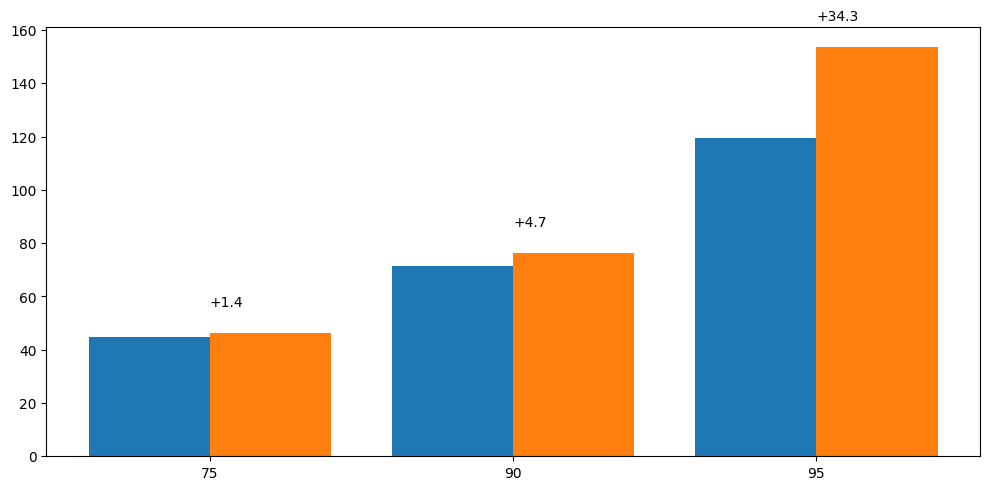

In [8]:
# Визуализация разницы в процентилях

a_percentiles = [np.percentile(group_a_data, p * 100) for p in percentiles]
b_percentiles = [np.percentile(group_b_data, p * 100) for p in percentiles]
differences = [b - a for a, b in zip(a_percentiles, b_percentiles)]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(percentiles))
width = 0.4
bars1 = ax.bar(x - width/2, a_percentiles, width)
bars2 = ax.bar(x + width/2, b_percentiles, width)

ax.set_xticks(x)
ax.set_xticklabels([f'{int(p*100)}' for p in percentiles])

#Добавим значения рассчитаной разинцы для процентилей
for i, diff in enumerate(differences):
    ax.text(i, max(a_percentiles[i], b_percentiles[i]) + 10, f'+{diff:.1f}')

plt.tight_layout()
plt.show()



Итоговые выводы:
1. Новый алгоритм "B" статистически значимо лучше старого алгоритма "A". Среднее время просмотра увеличилось на 27%.
2. Анализ по процентилям четко показал, что улучшения происходят преимущественно у самых активных пользователей (правый хвост распределения).
3. Анализ по процентилям окзался наиболее информативен, потому что: распределение данных ненормальное и имеет длинный правый хвост. Он также позволяет точно определить где именно происходят изменения. Тест Манна-Уитни не говорит где конкретно происходят изменения.
4. Рекомендуется запустить алгоритм "B" на всю аудиторию. Однако, возможно, для пассивных и средних пользовтелей следует улучшить существующий алгоритм "А", так как он показал малый прирост среднего времени просмотре.